# Nithish's contribution

In [8]:
import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# === Set device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# === Load metadata ===
train_df = pd.read_csv("/content/train_metadata.csv")
val_df = pd.read_csv("/content/val_metadata.csv")

# === Create full image paths ===
train_df['path'] = "/content/split_photos/train/" + train_df['photo_id'].astype(str) + '.jpg'
val_df['path']   = "/content/split_photos/val/" + val_df['photo_id'].astype(str) + '.jpg'

# === Filter metadata to only include images that actually exist ===
def file_exists(path):
    return os.path.exists(path)

train_df = train_df[train_df['path'].apply(file_exists)].reset_index(drop=True)
val_df   = val_df[val_df['path'].apply(file_exists)].reset_index(drop=True)

print(f"✅ Filtered Train: {len(train_df)} rows")
print(f"✅ Filtered Val:   {len(val_df)} rows")

# === Label encoding ===
labels = sorted(train_df['label'].unique())
label2idx = {label: idx for idx, label in enumerate(labels)}
train_df['label_idx'] = train_df['label'].map(label2idx)
val_df['label_idx'] = val_df['label'].map(label2idx)

# === Transformations ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === Custom Dataset ===
class PhotoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label_idx']
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# === Data Loaders ===
train_dataset = PhotoDataset(train_df, transform=transform)
val_dataset = PhotoDataset(val_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# === Load pretrained EfficientNet ===
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_features, len(labels))
efficientnet.to(device)

# === Loss and Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet.parameters(), lr=1e-4)

# === Training Loop ===
num_epochs = 10

for epoch in range(num_epochs):
    efficientnet.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(loss=loss.item())

    avg_loss = train_loss / total_train
    train_acc = train_correct / total_train
    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    # === Validation ===
    efficientnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}\n")


✅ Using device: cuda
✅ Filtered Train: 17192 rows
✅ Filtered Val:   2146 rows


Epoch 1/10: 100%|██████████| 538/538 [01:31<00:00,  5.89it/s, loss=0.286]

Train Loss: 0.3777 | Train Accuracy: 0.8797


Validation Accuracy: 0.9292



Epoch 2/10: 100%|██████████| 538/538 [01:31<00:00,  5.90it/s, loss=1.14]

...

Train Loss: 0.0272 | Train Accuracy: 0.9911


Validation Accuracy: 0.9371



Epoch 10/10: 100%|██████████| 538/538 [01:31<00:00,  5.85it/s, loss=0.0392]

Train Loss: 0.0248 | Train Accuracy: 0.9918


Validation Accuracy: 0.9287



In [9]:
# Save model
torch.save(efficientnet.state_dict(), "efficientnet_yelp.pth")

# Download in Colab
from google.colab import files
files.download("efficientnet_yelp.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

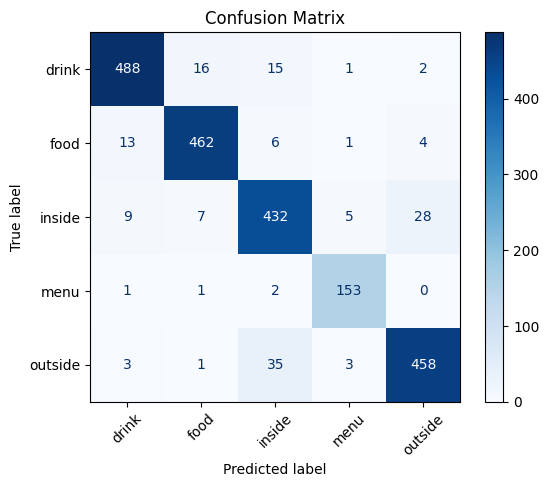


✅ Macro AUC Score: 0.9583


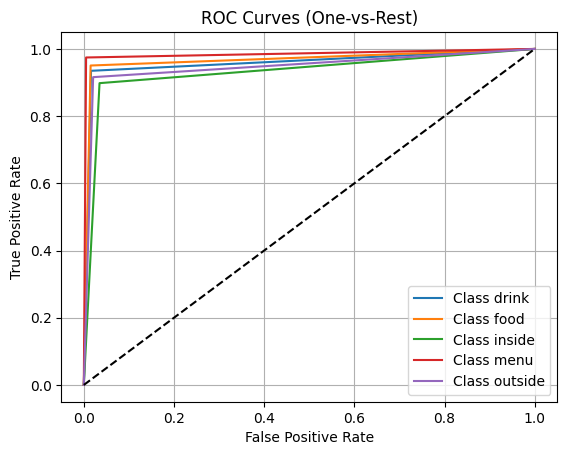

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# === Load saved predictions and true labels ===
y_pred = np.load("/content/efficientnet_preds.npy")
y_true = np.load("/content/efficientnet_true.npy")

# === Class names (adjust if needed) ===
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
n_classes = len(class_names)

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# === AUC Calculation ===
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_bin = label_binarize(y_pred, classes=list(range(n_classes)))

# Compute AUC score
auc_score = roc_auc_score(y_true_bin, y_pred_bin, average='macro', multi_class='ovr')
print(f"\n✅ Macro AUC Score: {auc_score:.4f}")

# === ROC Curve (Macro Average) ===
fpr = dict()
tpr = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    plt.plot(fpr[i], tpr[i], label=f"Class {class_names[i]}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


# Pranay's contribution

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# 🔒 Freeze the feature extractor
for param in efficientnet.features.parameters():
    param.requires_grad = False

# 🧠 Reinitialize the optimizer (only classifier layers are trainable)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, efficientnet.parameters()), lr=1e-3)

# ⚙️ Loss Function
criterion = nn.CrossEntropyLoss()

# 📊 Training Loop (3 Epochs)
num_epochs = 3
print("\n🚀 Iteration 1: Training with Frozen Feature Extractor\n")

for epoch in range(num_epochs):
    efficientnet.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Metrics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(loss=loss.item())

    avg_loss = train_loss / total_train
    train_acc = train_correct / total_train
    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    # === Validation ===
    efficientnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}\n")



🚀 Iteration 1: Training with Frozen Feature Extractor



Epoch 1/3: 100%|██████████| 538/538 [00:50<00:00, 10.66it/s, loss=0.0675]

Train Loss: 0.0129 | Train Accuracy: 0.9962


Validation Accuracy: 0.9306



Epoch 2/3: 100%|██████████| 538/538 [00:48<00:00, 11.02it/s, loss=0.000214]

Train Loss: 0.0147 | Train Accuracy: 0.9947


Validation Accuracy: 0.9306



Epoch 3/3: 100%|██████████| 538/538 [00:49<00:00, 10.97it/s, loss=0.000713]

Train Loss: 0.0136 | Train Accuracy: 0.9960


Validation Accuracy: 0.9292



In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet = efficientnet.to(device)

# ✅ Unfreeze last 3 blocks of EfficientNet
for param in efficientnet.features[-3:].parameters():
    param.requires_grad = True

# 🔁 Optimizer with updated trainable parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, efficientnet.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# 🏋️ Training Loop
num_epochs = 3

for epoch in range(num_epochs):
    efficientnet.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
        loop.set_postfix(loss=loss.item())

    print(f"✅ Epoch {epoch+1}: Train Accuracy: {train_correct / total_train:.4f}")

    # Validation
    efficientnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    print(f"📈 Validation Accuracy: {val_correct / val_total:.4f}\n")


Epoch 1/3: 100%|██████████| 538/538 [00:56<00:00,  9.52it/s, loss=0.00103]

✅ Epoch 1: Train Accuracy: 0.9950


📈 Validation Accuracy: 0.9296



Epoch 2/3: 100%|██████████| 538/538 [00:56<00:00,  9.52it/s, loss=0.31]

✅ Epoch 2: Train Accuracy: 0.9948


📈 Validation Accuracy: 0.9301



Epoch 3/3: 100%|██████████| 538/538 [00:55<00:00,  9.69it/s, loss=0.338]

✅ Epoch 3: Train Accuracy: 0.9951


📈 Validation Accuracy: 0.9287



In [26]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch
import numpy as np

efficientnet.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to NumPy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# 🎯 Accuracy
accuracy = (y_true == y_pred).mean()
print(f"✅ Accuracy: {accuracy:.4f}")

# 📊 Confusion Matrix
print("\n📌 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# 🧾 Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['drink', 'food', 'inside', 'menu', 'outside']))

# 📈 AUC Score (macro)
y_true_onehot = np.zeros_like(y_prob)
y_true_onehot[np.arange(len(y_true)), y_true] = 1
auc_score = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')
print(f"\n📈 AUC Score (macro): {auc_score:.4f}")


✅ Accuracy: 0.9287

📌 Confusion Matrix:
[[489  15  15   1   2]
 [ 12 467   4   1   2]
 [  8  11 426   4  32]
 [  1   2   3 147   4]
 [  2   2  29   3 464]]

📋 Classification Report:
              precision    recall  f1-score   support

       drink       0.96      0.94      0.95       522
        food       0.94      0.96      0.95       486
      inside       0.89      0.89      0.89       481
        menu       0.94      0.94      0.94       157
     outside       0.92      0.93      0.92       500

    accuracy                           0.93      2146
   macro avg       0.93      0.93      0.93      2146
weighted avg       0.93      0.93      0.93      2146


📈 AUC Score (macro): 0.9931


In [27]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=538dfc5c2462d4390a0f741f36d597dace98c1f188d9b66f61a3aa454c5b8775
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [29]:
# Save model state
torch.save(efficientnet.state_dict(), "efficientnet_iteration2.pth")

# Download the model
from google.colab import files
files.download("efficientnet_iteration2.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model Interpretability

  0%|          | 0/1000 [00:00<?, ?it/s]

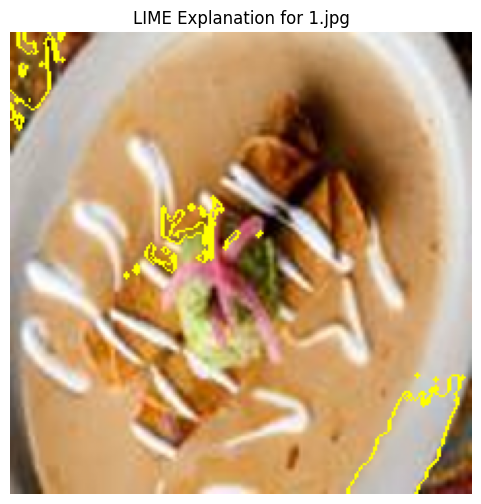

In [39]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from lime import lime_image
from torchvision import transforms
from skimage.segmentation import mark_boundaries

# ✅ Ensure your model is ready
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet = efficientnet.to(device)
efficientnet.eval()

# ✅ Sample image path
sample_path = "/content/1.jpg"

# ✅ Preprocessing: resize, normalize, and convert to tensor
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ✅ Load and process image
img_pil = Image.open(sample_path).convert('RGB')
img_tensor = transform(img_pil).unsqueeze(0).to(device)   # shape: (1, 3, 224, 224)
img_np = np.array(img_pil.resize((224, 224)))              # shape: (224, 224, 3)

# ✅ Define LIME-compatible prediction function
def predict_fn(images):
    images = torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = efficientnet(images)
        return torch.softmax(outputs, dim=1).cpu().numpy()

# ✅ LIME image explanation
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_np.astype(np.double),
    classifier_fn=predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# ✅ Display explanation mask
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation for 1.jpg")
plt.axis('off')
plt.show()


LLM Prompt
- help me with model tuning for this model
- how set the model if overfitting
- help me model interpretability using lime